In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression

**Does disagreement among equity factors today signal higher or lower market excess returns tomorrow?**

In Simpler Terms: **When stock market factors disagree with each other today, does the market behave differently tomorrow?**

Purpose of this project: **Testing whether days when equity factors disagree contain information about next-day market excess returns. I measured factor dispersion and evaluated its predictive value.**

**We want to investigate whether factor behavior can predict tomorrow's market excess return. A trading strategy, using momentum, mean reversion, and factor disagreement was developed with the intent of capturing short-term trends and seeing whether it could outperform the standard market.**

In [ ]:
df = pd.read_csv("F-F_Research_Data_5_Factors_2x3_daily.csv")
df.head()

,ID,Mkt-RF,SMB,HML,RMW,CMA,RF
0,19630701,-0.67,0.00,-0.34,-0.01,0.16,0.01
1,19630702,0.79,-0.26,0.26,-0.07,-0.20,0.01
2,19630703,0.63,-0.17,-0.09,0.18,-0.34,0.01
3,19630705,0.40,0.08,-0.27,0.09,-0.34,0.01
4,19630708,-0.63,0.04,-0.18,-0.29,0.14,0.01


**MKT-RF** = Market Excess Return (amount stock market beat cash that day)

**SMB**= Small Minus Big (Small-cap stocks vs large cap stocks)

**HML** = High Minus Low (Value stcoks vs growth stock)

**RMW**= Robust minus Weak (Profitable Firms vs unprofitable firms)

**CMA** = Conservative minus Aggressive (firms that invest conservatively vs aggressively)

**RF** = Risk-free rate (cash return for that day)


In [ ]:
#target
#Trying to predict tomorrow's market excess - what the minus 1 doe
df["target_next_mkt"] = df["Mkt-RF"].shift(-1)

In [ ]:
#Quantify Factor Disagreement
factor_cols = ["SMB", "HML", "RMW", "CMA"]
#You look at how spread out the factor returns are today
#High spread = factors strongly disagree
#Low spread = factors mostly agree

df["factor_disagreement"] = df[factor_cols].std(axis=1)
df["Mkt-RF_lag1"] = df["Mkt-RF"].shift(1)
df["Mkt-RF_lag5"] = df["Mkt-RF"].shift(5)
df["factor_disagreement_5d"] = df["factor_disagreement"].rolling(5).mean()

# Extreme disagreement (z-score)
df["factor_disagreement_z"] = (
    df["factor_disagreement"]
    - df["factor_disagreement"].rolling(252).mean()
) / df["factor_disagreement"].rolling(252).std()

# Volatility regime
df["market_vol_21d"] = df["Mkt-RF"].rolling(21).std()

# Factor vs market momentum
df["factor_momentum_5d"] = df[factor_cols].mean(axis=1).rolling(5).mean()
df["market_momentum_5d"] = df["Mkt-RF"].rolling(5).mean()
df["factor_minus_market_mom"] = (
    df["factor_momentum_5d"] - df["market_momentum_5d"]
)

# Interaction (stress signal)
df["disagreement_x_vol"] = (
    df["factor_disagreement_5d"] * df["market_vol_21d"]
)

**Factor Disagreement**: How much factors disagree about the state of the economy (also use in this case relative to all history and a rolling calculator)

**Mkt-RF Lag 1**: Short-term momentum.

**Mkt-RF Lag 5**: Market excess return from one week ago.

**Factor Momentum**: Average recent performance of the non-market factors.

**Disagreement Volatility:** Stress Interaction Sinal

**Market Reversal:** Represents short-term mean reversion.

In [ ]:
features = [
    "Mkt-RF_lag1",
    "Mkt-RF_lag5",
    "factor_disagreement_5d",
    "factor_disagreement_z",
    "market_vol_21d",
    "factor_minus_market_mom",
    "disagreement_x_vol"
]
data = df[features + ["target_next_mkt"]].dropna()

**Train and Testing**

In [ ]:
split_idx = int(len(data) * 0.75)
train = data.iloc[:split_idx]
test  = data.iloc[split_idx:]

X_train = train[features]
y_train = train["target_next_mkt"]

X_test  = test[features]
y_test  = test["target_next_mkt"]

In [ ]:
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

Ridge()

**Optimal Trading Strategy**

In [ ]:
test["prediction"] = model.predict(X_test)
# Trading rule (confidence-weighted)
test["position"] = test["prediction"] / test["prediction"].std()
test["position"] = test["position"].clip(-2, 2)

test["strategy_return"] = test["position"] * test["target_next_mkt"]

test["cum_strategy"] = (1 + test["strategy_return"]/100).cumprod()
test["cum_market"]  = (1 + test["target_next_mkt"]/100).cumprod()

/tmp/ipython-input-915/841754951.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["prediction"] = model.predict(X_test)
/tmp/ipython-input-915/841754951.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["position"] = test["prediction"] / test["prediction"].std()
/tmp/ipython-input-915/841754951.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://

**Prediction:** Prediction of tomorrow's market excess return for each day

**Position**: Risk Control rule that prevents confidence/bets from being too big or small in extreme situations

**Strategy Return:** Daily strategy profit or loss

**Cumulative Strategy**: Compound Daily Strategy Returns Over Time if we had invested $1 in our strategy

**Cumulative Market**: Compound Daily Strategy Returns Over Time if we had invested $1 in the market

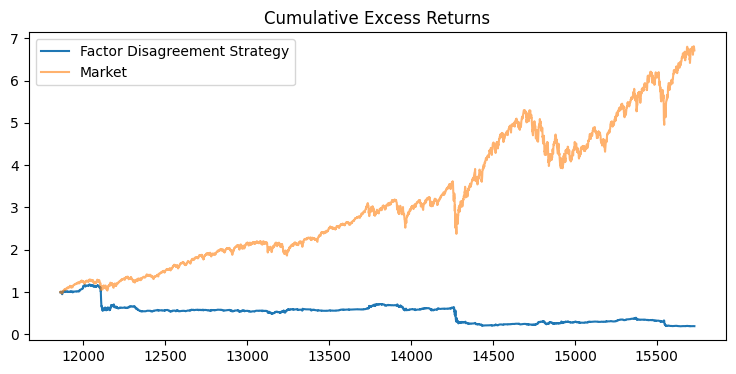

In [ ]:
plt.figure(figsize=(9,4))
plt.plot(test.index, test["cum_strategy"], label="Factor Disagreement Strategy")
plt.plot(test.index, test["cum_market"], label="Market", alpha=0.6)
plt.legend()
plt.title("Cumulative Excess Returns")
plt.show()

**Evaluation Metrics**

**RMSE** = prediction accuracy

**Sharpe ratio** = risk-adjusted performance

**Information coefficient** = correlation between predictions and outcomes

In [ ]:
def sharpe_ratio(returns, periods=252):
    return returns.mean() / returns.std() * np.sqrt(periods)

def information_coefficient(preds, actuals):
    return np.corrcoef(preds, actuals)[0, 1]

print("RMSE:", mean_squared_error(y_test, test["prediction"]))
print("Sharpe:", sharpe_ratio(test["strategy_return"]))
print("IC:", information_coefficient(test["prediction"], y_test))

coef = pd.Series(model.coef_, index=features).sort_values()
print(coef)

RMSE: 1.2610438583842778
Sharpe: -0.3515816355770034
IC: -0.1106552666885318
factor_minus_market_mom   -0.090309
Mkt-RF_lag1               -0.057144
market_vol_21d            -0.015407
Mkt-RF_lag5               -0.003241
disagreement_x_vol         0.008905
factor_disagreement_z      0.012141
factor_disagreement_5d     0.041230
dtype: float64
